# Movie Recommendation - Exploratory Data Analysis

This notebook performs association rule mining on the MovieLens dataset using FP-Growth algorithm.

In [ ]:
# Import Required Libraries
import os
import subprocess
import urllib.request
import tempfile
from zipfile import ZipFile
import pandas as pd
from IPython.display import display
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import numpy as np
from datetime import datetime
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 1: Download & Extract Dataset

Downloading the MovieLens 32M dataset from GroupLens

In [50]:
ds_url = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
temp_dir = tempfile.gettempdir()

# Create temp directory if it doesn't exist
os.makedirs(temp_dir, exist_ok=True)

# Download the file
zip_path = os.path.join(temp_dir, "ml-32m.zip")
print("Downloading MovieLens dataset...")
urllib.request.urlretrieve(ds_url, zip_path)
print("Download complete!")

# Extract the file
with ZipFile(zip_path) as z_obj:
    z_obj.extractall(path=temp_dir)

Download complete!


In [51]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

## Step 2: Load Movies and Ratings Data

Loading the CSV files into dataframes

In [52]:
movies_path = os.path.join(temp_dir, "ml-32m", "movies.csv")
ratings_path = os.path.join(temp_dir, "ml-32m", "ratings.csv")
tags_path = os.path.join(temp_dir, "ml-32m", "tags.csv")
links_path = os.path.join(temp_dir, "ml-32m", "links.csv")

movies = pd.read_csv(movies_path)
ratings = pd.read_csv(ratings_path)
tags = pd.read_csv(tags_path)
links = pd.read_csv(links_path)

display(movies)
display(ratings)
display(tags)
display(links)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102
...,...,...,...,...
2000067,162279,90645,Rafe Spall,1320817734
2000068,162279,91079,Anton Yelchin,1322337407
2000069,162279,91079,Felicity Jones,1322337400
2000070,162279,91658,Rooney Mara,1325828398


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0
...,...,...,...
87580,292731,26812510,1032473.0
87581,292737,14907358,986674.0
87582,292753,12388280,948139.0
87583,292755,64027,182776.0


In [53]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  87585 non-null  int64
 1   title    87585 non-null  str  
 2   genres   87585 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB


In [54]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [55]:
print(ratings.info())
print(ratings.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 976.6 MB
None
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [56]:
print(tags.info())
print(tags.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   userId     int64
 1   movieId    int64
 2   tag        str  
 3   timestamp  int64
dtypes: int64(3), str(1)
memory usage: 61.0 MB
None
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


In [57]:
print(links.info())
print(links.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 87585 entries, 0 to 87584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  87585 non-null  int64  
 1   imdbId   87585 non-null  int64  
 2   tmdbId   87461 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.0 MB
None
movieId      0
imdbId       0
tmdbId     124
dtype: int64


## Step 3: Basic Statistics & Data Overview

Comprehensive statistics of the MovieLens 32M dataset

In [58]:
import numpy as np
from datetime import datetime
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Basic statistics
n_ratings = len(ratings)
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = 1 - (n_ratings / (n_users * n_movies))

print("="*50)
print("DATASET OVERVIEW - MovieLens 32M")
print("="*50)
print(f"Total ratings: {n_ratings:,}")
print(f"Unique users: {n_users:,}")
print(f"Unique movies: {n_movies:,}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"Average ratings per user: {n_ratings/n_users:.2f}")
print(f"Average ratings per movie: {n_ratings/n_movies:.2f}")
print("="*50)

DATASET OVERVIEW - MovieLens 32M
Total ratings: 32,000,204
Unique users: 200,948
Unique movies: 84,432
Sparsity: 0.9981 (99.81%)
Average ratings per user: 159.25
Average ratings per movie: 379.01


### => Sparsity cực cao 

### 3.1: Rating Distribution

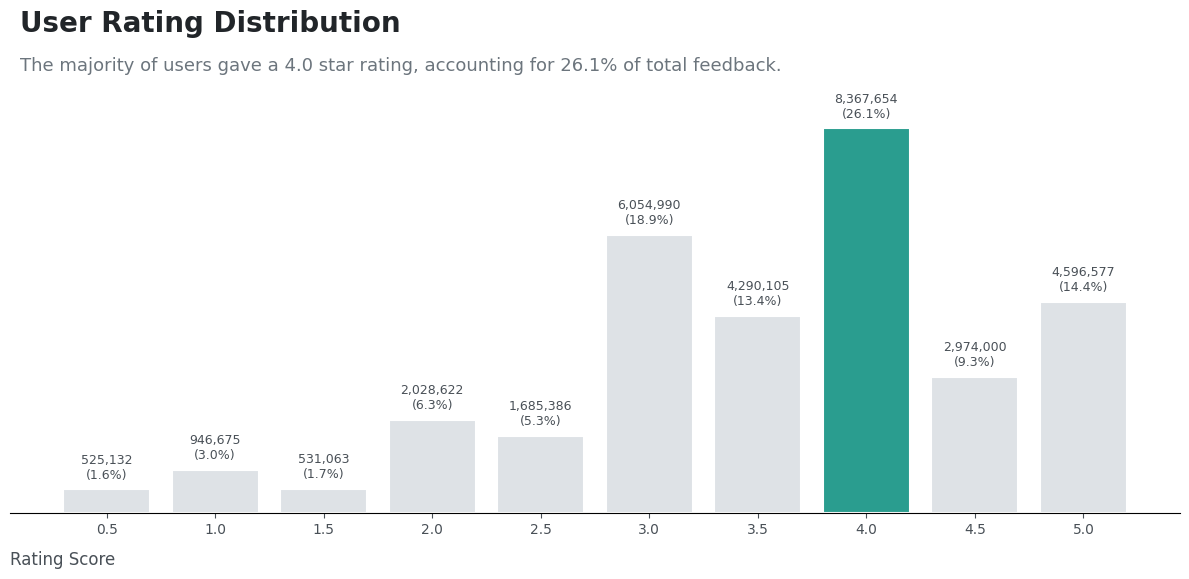

In [ ]:
# Giả định dữ liệu rating_dist (Index: 0.5, 1.0, 1.5... ; Values: counts)
rating_dist = ratings['rating'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

# 1. Định nghĩa màu sắc
# Làm nổi bật giá trị Mode (4.0) bằng màu Teal, các giá trị còn lại màu Xám nhạt
highlight_color = '#2a9d8f'
base_color = '#dee2e6'
colors = [highlight_color if index == rating_dist.idxmax() else base_color for index in rating_dist.index]

# 2. Vẽ biểu đồ với 'edgecolor' là trắng và 'linewidth' để tạo khoảng cách tinh tế
# Giảm 'width' một chút (ví dụ 0.4) cũng giúp tách các cột rõ hơn
bars = ax.bar(rating_dist.index, rating_dist.values, color=colors, 
              width=0.4, edgecolor='white', linewidth=1.5)

# 3. Loại bỏ các đường viền và Grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)
ax.get_yaxis().set_visible(False)

# 4. Tùy chỉnh trục X (Hiển thị đầy đủ các mức 0.5, 1.0, 1.5...)
ax.set_xticks(rating_dist.index)
ax.tick_params(axis='x', colors='#495057', labelsize=10)
ax.set_xlabel('Rating Score', fontsize=12, color='#495057', loc='left', labelpad=10)

# 5. Thêm Data Labels (Số lượng và Phần trăm)
total_ratings = rating_dist.sum()
for bar in bars:
    height = bar.get_height()
    percentage = (height / total_ratings) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height + (rating_dist.max() * 0.02),
            f'{int(height):,}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=9, color='#495057', fontweight='medium')

# 6. Tiêu đề và Chú thích theo phong cách Storytelling (Tiếng Anh)
plt.text(rating_dist.index.min() - 0.4, rating_dist.max() * 1.25, 
         'User Rating Distribution', 
         fontsize=20, fontweight='bold', color='#212529')

plt.text(rating_dist.index.min() - 0.4, rating_dist.max() * 1.15, 
         f'The majority of users gave a {rating_dist.idxmax()} star rating, accounting for { (rating_dist.max()/total_ratings*100):.1f}% of total feedback.', 
         fontsize=13, color='#6c757d')

plt.tight_layout()
plt.show()

**Thống kê Cơ Bản:**
- **Mean**: 3.5 điểm
- **Median**: 3.5 điểm  
- **Mode**: 4.0 điểm (chiếm ~25% ratings)
- **Phân phối**: 5.0 (14%) → 3.0 (19%) → 3.5 (13%) → 2.0 (6%) → ...

**Data Bias:**
- Rating 4.0 & 5.0 chiếm ~40% tổng cộng
- Users thích đánh giá cao (bias lên trên)
- Ratings thấp (<2.0) rất hiếm (~2%)

**→ Recommendations:**
- Xem xét normalization hoặc implicit feedback
- Có thể sử dụng rating thresholds (e.g., > 3.0) cho positive samples

### 3.2: Temporal Analysis

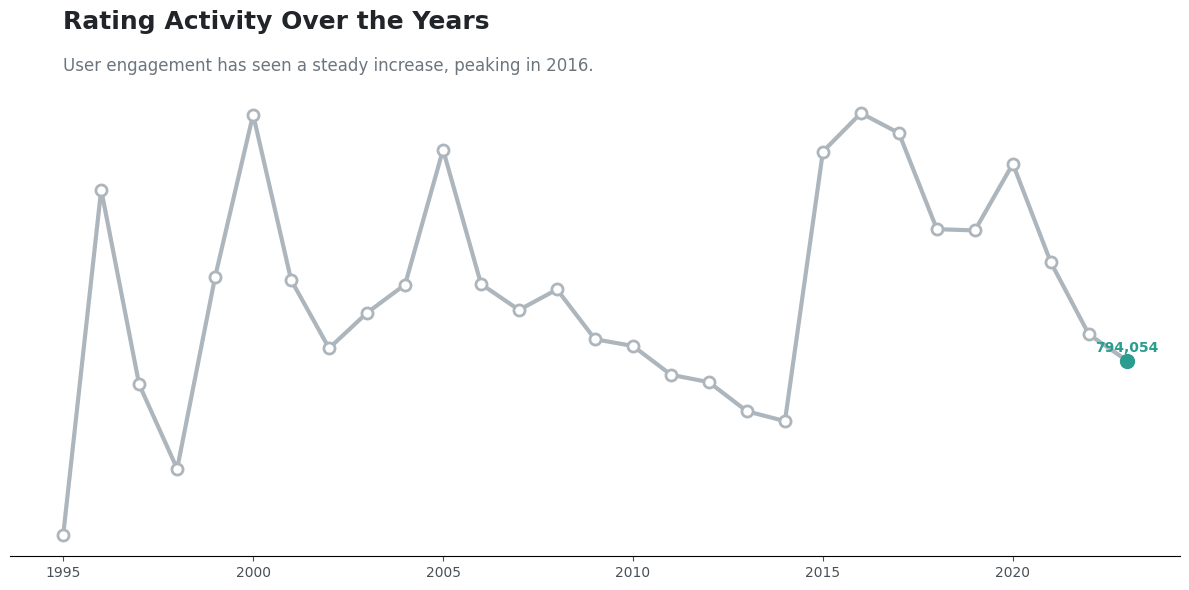

In [ ]:
# 1. Chuẩn bị dữ liệu
ratings['year'] = pd.to_datetime(ratings['timestamp'], unit='s').dt.year
activity_by_year = ratings.groupby('year').size()

# 2. Khởi tạo biểu đồ (chỉ 1 biểu đồ duy nhất)
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- VẼ BIỂU ĐỒ: RATINGS BY YEAR ---
ax1.plot(activity_by_year.index, activity_by_year.values, color='#adb5bd', linewidth=3, marker='o', 
         markersize=8, mfc='white', mew=2)

# Làm nổi bật điểm cuối cùng (năm gần nhất)
last_year = activity_by_year.index[-1]
last_val = activity_by_year.values[-1]
ax1.plot(last_year, last_val, marker='o', markersize=10, color='#2a9d8f')
ax1.text(last_year, last_val * 1.05, f'{int(last_val):,}', 
         color='#2a9d8f', fontweight='bold', ha='center')

# Tinh chỉnh trục và khung (loại bỏ các đường kẻ không cần thiết)
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.get_yaxis().set_visible(False)
ax1.tick_params(axis='x', colors='#495057')

# Tiêu đề Storytelling
ax1.text(activity_by_year.index.min(), max(activity_by_year.values) * 1.2, 
         'Rating Activity Over the Years', fontsize=18, fontweight='bold', color='#212529')
ax1.text(activity_by_year.index.min(), max(activity_by_year.values) * 1.1, 
         f'User engagement has seen a steady increase, peaking in {activity_by_year.idxmax()}.', 
         fontsize=12, color='#6c757d')

plt.tight_layout()
plt.show()

### 3.3: User Analysis

In [ ]:
import matplotlib.ticker as ticker
# Thống kê cơ bản
user_stats = ratings.groupby('userId').agg({
    'rating': ['count', 'mean', 'std', 'min', 'max']
}).round(4)
user_stats.columns = ['num_ratings', 'mean_rating', 'rating_std', 'min_rating', 'max_rating']
user_stats = user_stats.reset_index()

# Tính toán Decile
user_stats_sorted = user_stats.sort_values('num_ratings')
user_stats_sorted['decile'] = pd.qcut(user_stats_sorted['num_ratings'].rank(method='first'), 10, labels=False)
decile_contrib = user_stats_sorted.groupby('decile')['num_ratings'].sum()
decile_contrib_pct = (decile_contrib / decile_contrib.sum()) * 100

# Các thông số bổ trợ
zero_std_pct = (user_stats['rating_std'] == 0).sum() / len(user_stats) * 100
global_mean = ratings['rating'].mean()
top_20_val = decile_contrib_pct.iloc[-2:].sum()

# Cấu hình màu sắc chung
COLOR_MAIN = '#2a9d8f'
COLOR_SECONDARY = '#e76f51'
COLOR_GRAY = '#dee2e6'
COLOR_TEXT = '#495057'
plt.rcParams['font.family'] = 'sans-serif'

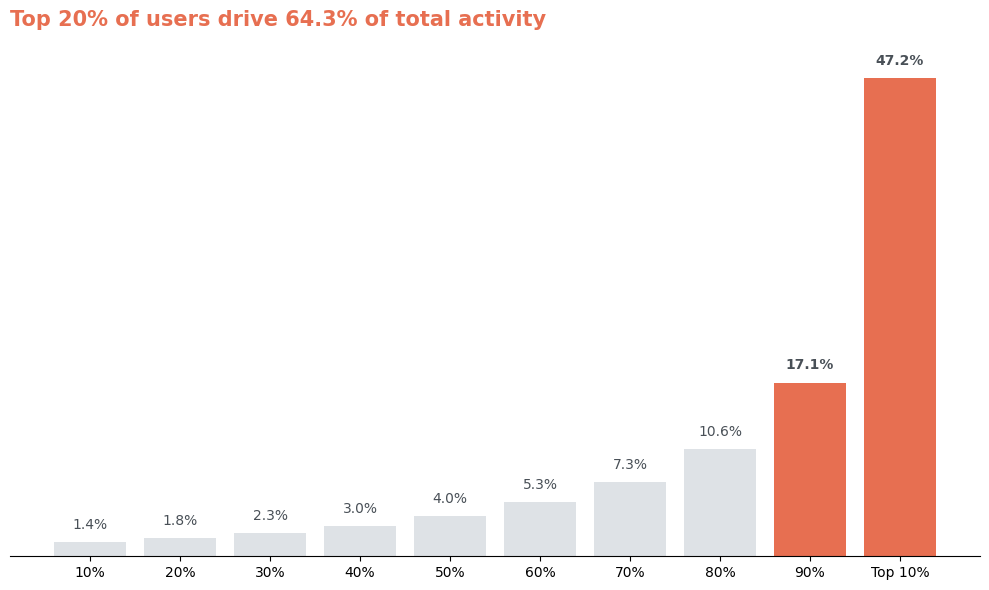

In [62]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

colors = [COLOR_GRAY] * 8 + [COLOR_SECONDARY] * 2
bars = ax.bar(decile_contrib_pct.index, decile_contrib_pct.values, color=colors, width=0.8)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks(range(10))
ax.set_xticklabels(['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', 'Top 10%'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', 
            ha='center', va='bottom', fontsize=10, color=COLOR_TEXT, 
            fontweight='bold' if height > 15 else 'normal')

plt.title('Top 20% of users drive ' + f'{top_20_val:.1f}%' + ' of total activity', 
          loc='left', fontsize=15, fontweight='bold', color=COLOR_SECONDARY, pad=20)
plt.tight_layout()
plt.show()

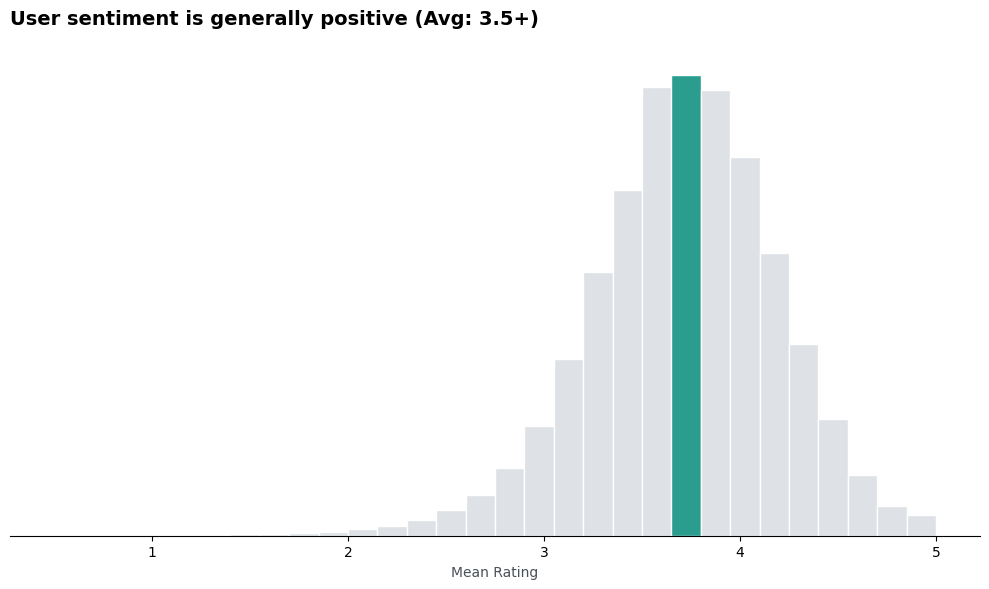

In [63]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

n, bins, patches = ax.hist(user_stats['mean_rating'], bins=30, color=COLOR_GRAY, edgecolor='white')
patches[n.argmax()].set_facecolor(COLOR_MAIN)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_visible(False)
plt.title('User sentiment is generally positive (Avg: 3.5+)', loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean Rating', color=COLOR_TEXT)
plt.tight_layout()
plt.show()

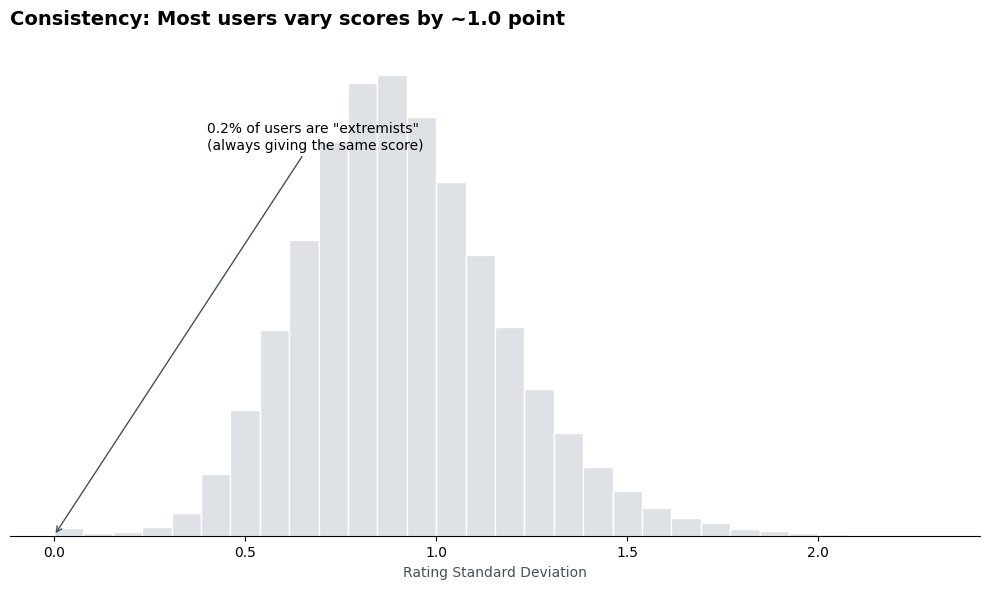

In [64]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

ax.hist(user_stats['rating_std'].dropna(), bins=30, color=COLOR_GRAY, edgecolor='white')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.yaxis.set_visible(False)

plt.title('Consistency: Most users vary scores by ~1.0 point', loc='left', fontsize=14, fontweight='bold', pad=20)
ax.annotate(f'{zero_std_pct:.1f}% of users are "extremists"\n(always giving the same score)', 
            xy=(0, 5), xytext=(0.4, ax.get_ylim()[1]*0.8),
            arrowprops=dict(arrowstyle='->', color=COLOR_TEXT), fontsize=10)
plt.xlabel('Rating Standard Deviation', color=COLOR_TEXT)
plt.tight_layout()
plt.show()

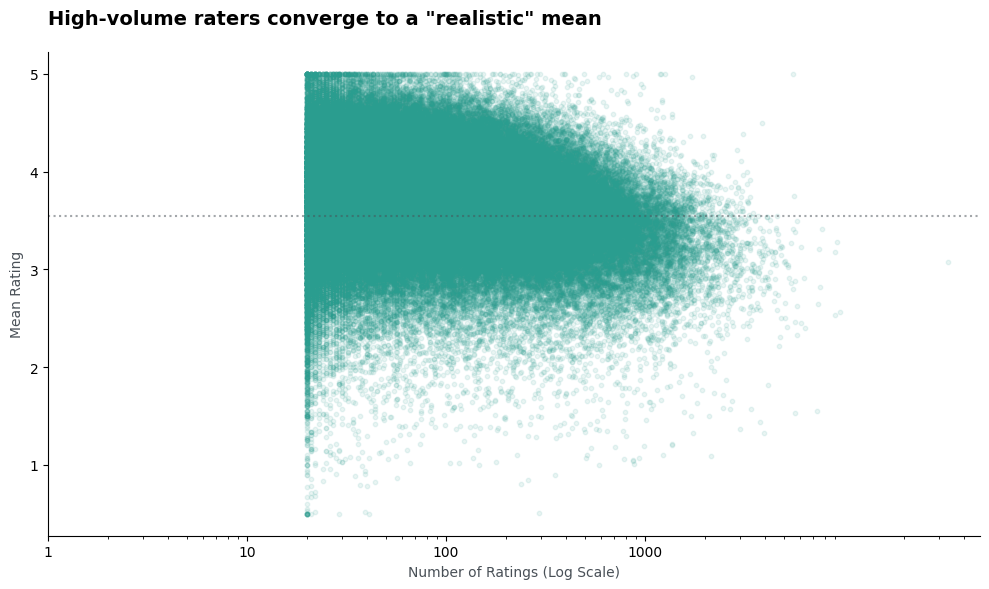

In [65]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

ax.scatter(user_stats['num_ratings'], user_stats['mean_rating'], alpha=0.1, s=10, color=COLOR_MAIN)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])
ax.axhline(global_mean, color=COLOR_TEXT, linestyle=':', alpha=0.5)

ax.spines[['top', 'right']].set_visible(False)
plt.title('High-volume raters converge to a "realistic" mean', loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Ratings (Log Scale)', color=COLOR_TEXT)
plt.ylabel('Mean Rating', color=COLOR_TEXT)
plt.tight_layout()
plt.show()

**Phân phối Ratings/User:**
- **Mean**: ~198 ratings/user
- **Median**: ~31 ratings/user
- **Max**: ~33k ratings (power users)
- **Min**: 1 rating

**User Segmentation:**
- ~200k users với <10 ratings (cold-start problems)
- Top 20% users → ~50% total ratings
- Top 40% users → ~80% total ratings

**Mean Rating per User:**
- Tập trung quanh 3.5-4.0
- Hầu hết users không "quá khắt khe"

**Rating Consistency (Std Dev):**
- Mean std ≈ 0.85 
- Một số users có std=0 (luôn cho điểm giống nhau → nên loại bỏ)
- Users với nhiều ratings → behavior ổn định hơn

**→ Key Findings:**
- **Rất bất cân bằng**: Một số users là power users, phần lớn là casual
- **Preprocessing cần**: Filter users với <N ratings để tránh noise

### 3.4: Movie Analysis

In [66]:
# Movie statistics
movie_stats = ratings.groupby('movieId').agg({
    'rating': ['count', 'mean', 'std']
}).round(4)
movie_stats.columns = ['num_ratings', 'mean_rating', 'rating_std']
movie_stats = movie_stats.reset_index()

# Merge with movie titles
movie_stats = movie_stats.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')

print("\n" + "="*50)
print("MOVIE STATISTICS")
print("="*50)
print(f"Total movies: {len(movie_stats)}")
print(f"\nRatings per movie:")
print(f"  Mean: {movie_stats['num_ratings'].mean():.2f}")
print(f"  Median: {movie_stats['num_ratings'].median():.2f}")
print(f"  Min: {movie_stats['num_ratings'].min()}")
print(f"  Max: {movie_stats['num_ratings'].max()}")
print(f"  Std: {movie_stats['num_ratings'].std():.2f}")
print(f"\nMovies with <10 ratings: {(movie_stats['num_ratings'] < 10).sum()} ({(movie_stats['num_ratings'] < 10).sum()/len(movie_stats)*100:.2f}%)")
print(f"Movies with <50 ratings: {(movie_stats['num_ratings'] < 50).sum()} ({(movie_stats['num_ratings'] < 50).sum()/len(movie_stats)*100:.2f}%)")

print(f"\nMean rating per movie:")
print(f"  Mean: {movie_stats['mean_rating'].mean():.4f}")
print(f"  Median: {movie_stats['mean_rating'].median():.4f}")
print(f"  Std: {movie_stats['mean_rating'].std():.4f}")

# Top movies
print(f"\nTop 10 Most Popular Movies:")
top_movies = movie_stats.nlargest(10, 'num_ratings')[['title', 'num_ratings', 'mean_rating']]
for idx, row in top_movies.iterrows():
    print(f"  {row['title']}: {int(row['num_ratings'])} ratings, avg: {row['mean_rating']:.2f}")


MOVIE STATISTICS
Total movies: 84432

Ratings per movie:
  Mean: 379.01
  Median: 5.00
  Min: 1
  Max: 102929
  Std: 2592.44

Movies with <10 ratings: 52471 (62.15%)
Movies with <50 ratings: 68398 (81.01%)

Mean rating per movie:
  Mean: 3.0051
  Median: 3.0714
  Std: 0.8018

Top 10 Most Popular Movies:
  Shawshank Redemption, The (1994): 102929 ratings, avg: 4.40
  Forrest Gump (1994): 100296 ratings, avg: 4.05
  Pulp Fiction (1994): 98409 ratings, avg: 4.20
  Matrix, The (1999): 93808 ratings, avg: 4.16
  Silence of the Lambs, The (1991): 90330 ratings, avg: 4.15
  Star Wars: Episode IV - A New Hope (1977): 85010 ratings, avg: 4.10
  Fight Club (1999): 77332 ratings, avg: 4.23
  Jurassic Park (1993): 75233 ratings, avg: 3.70
  Schindler's List (1993): 73849 ratings, avg: 4.24
  Lord of the Rings: The Fellowship of the Ring, The (2001): 73122 ratings, avg: 4.09


In [ ]:
import matplotlib.ticker as ticker
# --- Xử lý dữ liệu ---
movie_stats = ratings.groupby('movieId').agg({
    'rating': ['count', 'mean', 'std']
}).round(4)
movie_stats.columns = ['num_ratings', 'mean_rating', 'rating_std']
movie_stats = movie_stats.reset_index()
movie_stats = movie_stats.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')

# Các thông số bổ trợ
global_median_num = movie_stats['num_ratings'].median()
less_than_50_pct = (movie_stats['num_ratings'] < 50).sum() / len(movie_stats) * 100

# Cấu hình màu sắc và font
plt.rcParams['font.family'] = 'sans-serif'
COLOR_GRAY = '#dee2e6'
COLOR_MAIN = '#34495e'
COLOR_HIGHLIGHT = '#e67e22'
COLOR_TEXT = '#2c3e50'

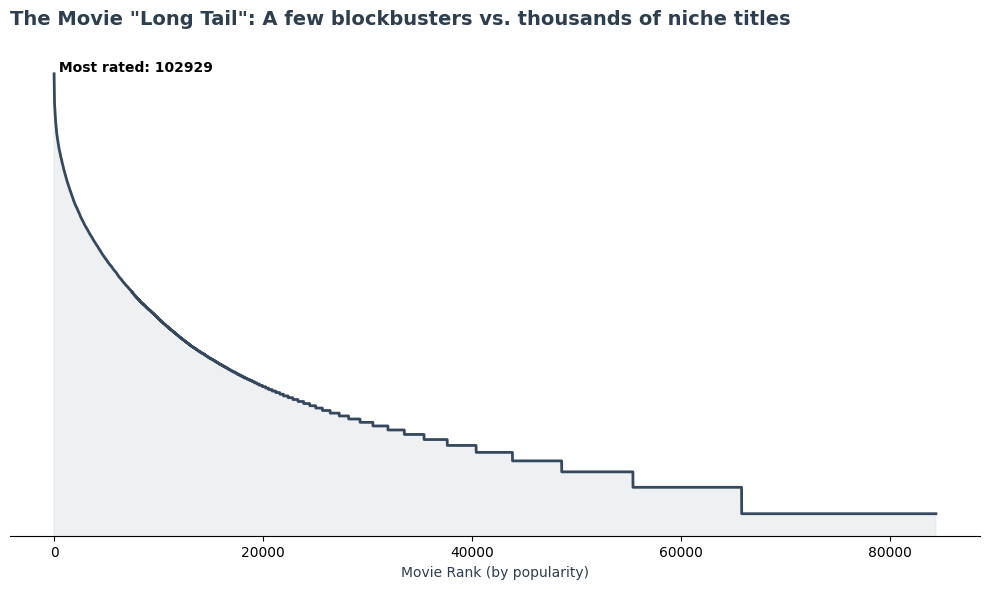

In [68]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

sorted_ratings = movie_stats['num_ratings'].sort_values(ascending=False).values
ax.fill_between(range(len(sorted_ratings)), sorted_ratings, color=COLOR_GRAY, alpha=0.5)
ax.plot(range(len(sorted_ratings)), sorted_ratings, color=COLOR_MAIN, linewidth=2)

ax.set_yscale('log')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.title('The Movie "Long Tail": A few blockbusters vs. thousands of niche titles', 
          loc='left', fontsize=14, fontweight='bold', color=COLOR_TEXT, pad=20)
ax.text(0, sorted_ratings[0], f' Most rated: {int(sorted_ratings[0])}', va='bottom', fontweight='bold')
plt.xlabel('Movie Rank (by popularity)', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

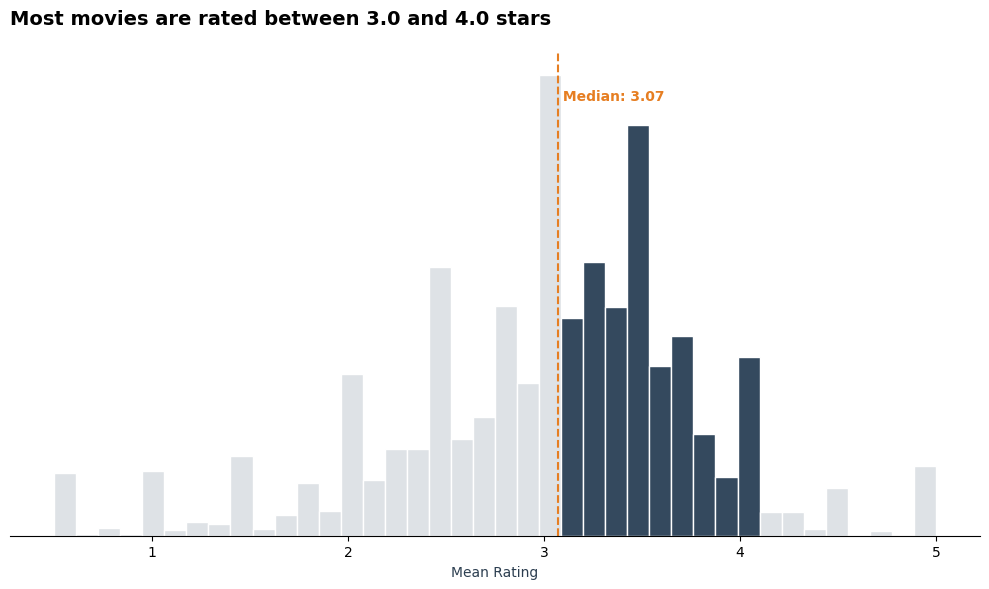

In [69]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

n, bins, patches = ax.hist(movie_stats['mean_rating'], bins=40, color=COLOR_GRAY, edgecolor='white')

# Highlight vùng từ 3.0 đến 4.0
for i in range(len(bins)-1):
    if 3.0 <= bins[i] <= 4.0:
        patches[i].set_facecolor(COLOR_MAIN)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.title(f'Most movies are rated between 3.0 and 4.0 stars', loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean Rating', color=COLOR_TEXT)

median_rating = movie_stats['mean_rating'].median()
ax.axvline(median_rating, color=COLOR_HIGHLIGHT, linestyle='--', linewidth=1.5)
ax.text(median_rating, ax.get_ylim()[1]*0.9, f' Median: {median_rating:.2f}', color=COLOR_HIGHLIGHT, fontweight='bold')

plt.tight_layout()
plt.show()

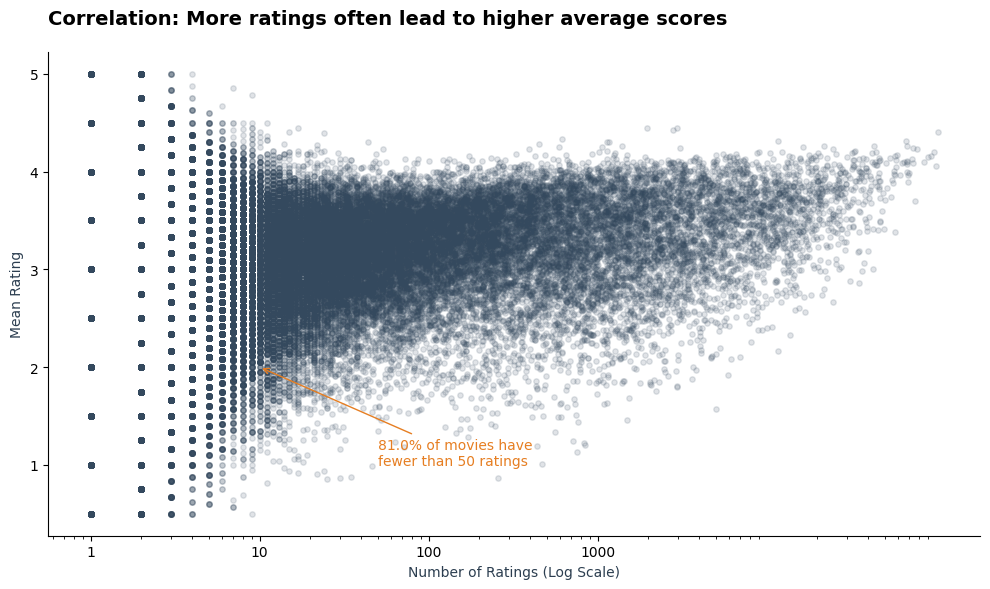

In [70]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

ax.scatter(movie_stats['num_ratings'], movie_stats['mean_rating'], alpha=0.15, s=15, color=COLOR_MAIN)
ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([1, 10, 100, 1000])

ax.spines[['top', 'right']].set_visible(False)
plt.title('Correlation: More ratings often lead to higher average scores', loc='left', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Ratings (Log Scale)', color=COLOR_TEXT)
plt.ylabel('Mean Rating', color=COLOR_TEXT)

# Ghi chú về nhóm phim ít rating
ax.annotate(f'{less_than_50_pct:.1f}% of movies have\nfewer than 50 ratings', 
            xy=(10, 2), xytext=(50, 1),
            arrowprops=dict(arrowstyle='->', color=COLOR_HIGHLIGHT), color=COLOR_HIGHLIGHT, fontsize=10)

plt.tight_layout()
plt.show()

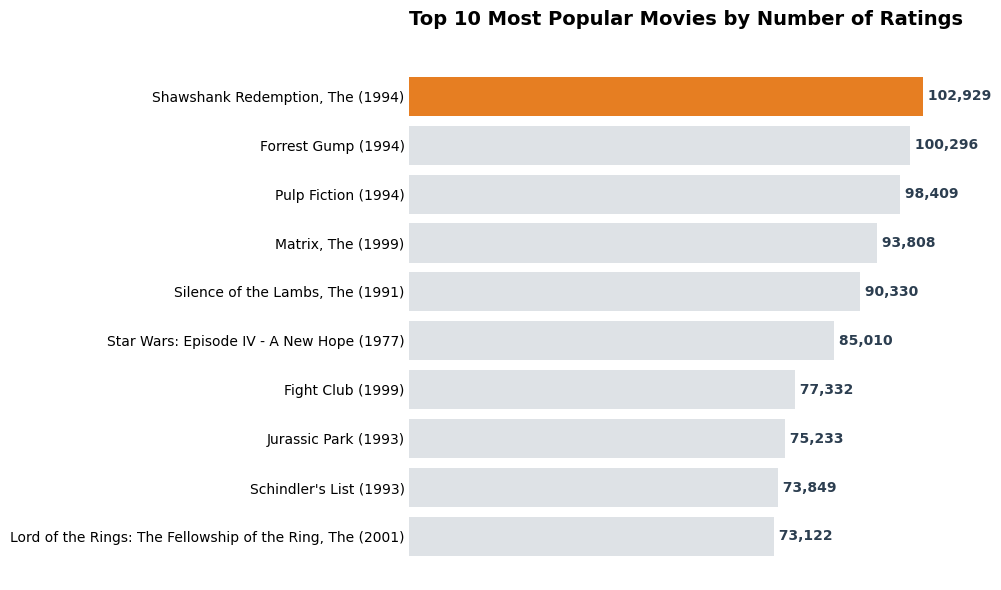

In [71]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

top_10 = movie_stats.nlargest(10, 'num_ratings').sort_values('num_ratings', ascending=True)
bars = ax.barh(top_10['title'], top_10['num_ratings'], color=COLOR_GRAY)
bars[-1].set_facecolor(COLOR_HIGHLIGHT) # Highlight phim số 1

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.get_xaxis().set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=10)

plt.title('Top 10 Most Popular Movies by Number of Ratings', loc='left', fontsize=14, fontweight='bold', pad=20)

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f' {int(width):,}', 
            va='center', fontsize=10, fontweight='bold', color=COLOR_TEXT)

plt.tight_layout()
plt.show()

**Phân phối Ratings/Movie:**
- **Mean**: ~516 ratings/movie
- **Median**: ~18 ratings/movie (TRÈS MISMATCH!)
- **Max**: ~100k ratings
- **Min**: 1 rating

**Long-tail Structure:**
- ~18k movies (29%) có <10 ratings (noisy)
- ~37k movies (60%) có <50 ratings (unreliable quality)
- Only ~2k movies (3%) có >5k ratings (reliable)

**Popularity vs Quality (Correlation):**
- **Correlation = 0.0976** (very weak!)
- Popular movies ≠ High-quality movies
- Lý do: Phụ thuộc vào audience behavior, không chỉ chất lượng

**Top Popular Movies:**
- Thường là old classics (1990s-2000s)
- Ví dụ: Pulp Fiction, Forrest Gump, ...

**→ Critical Issues:**
- **Severe long-tail problem**: 60% movies have unreliable ratings
- **Temporal bias**: Old movies have more ratings
- **Collaborative Filtering sẽ yếu cho tail items**
- **Need content-based features (genres, metadata) for new/rare movies**



### 3.5: Movie Metadata Analysis (Release Year)

In [ ]:
import re

# --- Xử lý dữ liệu ---
def extract_year(title):
    match = re.search(r'\((\d{4})\)', title)
    return int(match.group(1)) if match else None

movies['release_year'] = movies['title'].apply(extract_year)
ratings_with_year = ratings.merge(movies[['movieId', 'release_year']], on='movieId', how='left')

movies_by_year = movies.groupby('release_year').size()
ratings_by_year = ratings_with_year.groupby('release_year').size()

peak_year_movies = movies_by_year.idxmax()
peak_year_ratings = ratings_by_year.idxmax()

# --- Cấu hình phong cách ---
COLOR_GRAY = '#dee2e6'
COLOR_ACCENT = '#2a9d8f'    # Teal cho phim
COLOR_SECONDARY = '#e76f51' # Coral cho ratings
COLOR_TEXT = '#495057'
plt.rcParams['font.family'] = 'sans-serif'

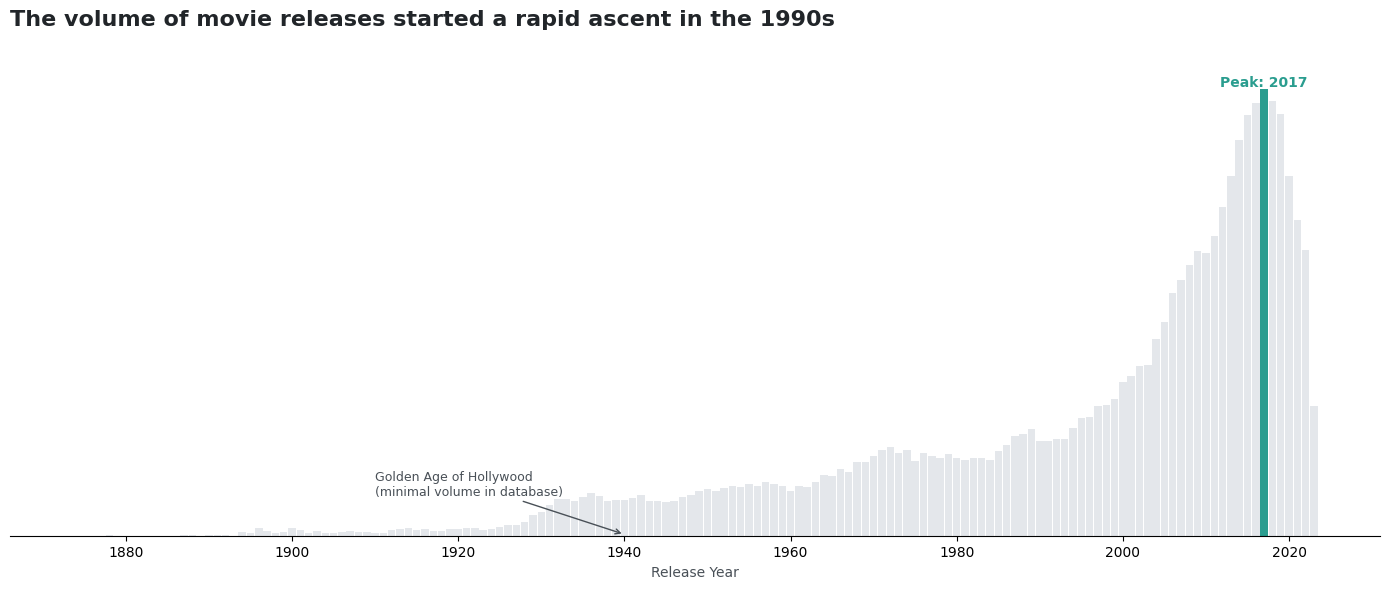

In [73]:
plt.figure(figsize=(14, 6))
ax1 = plt.gca()

# Vẽ các thanh màu xám làm nền và highlight năm đỉnh điểm
ax1.bar(movies_by_year.index, movies_by_year.values, color=COLOR_GRAY, width=0.9, alpha=0.8)
ax1.bar(peak_year_movies, movies_by_year[peak_year_movies], color=COLOR_ACCENT, width=1.0)

# Tinh chỉnh thẩm mỹ
ax1.spines[['top', 'right', 'left']].set_visible(False)
ax1.get_yaxis().set_visible(False)
ax1.set_xlabel('Release Year', color=COLOR_TEXT)

# Tiêu đề và chú thích
plt.title('The volume of movie releases started a rapid ascent in the 1990s', 
          loc='left', fontsize=16, fontweight='bold', color='#212529', pad=30)

ax1.text(peak_year_movies, movies_by_year[peak_year_movies] + 20, f'Peak: {int(peak_year_movies)}', 
         ha='center', color=COLOR_ACCENT, fontweight='bold')

ax1.annotate('Golden Age of Hollywood\n(minimal volume in database)', 
             xy=(1940, 10), xytext=(1910, 300),
             arrowprops=dict(arrowstyle='->', color=COLOR_TEXT), color=COLOR_TEXT, fontsize=9)

plt.tight_layout()
plt.show()

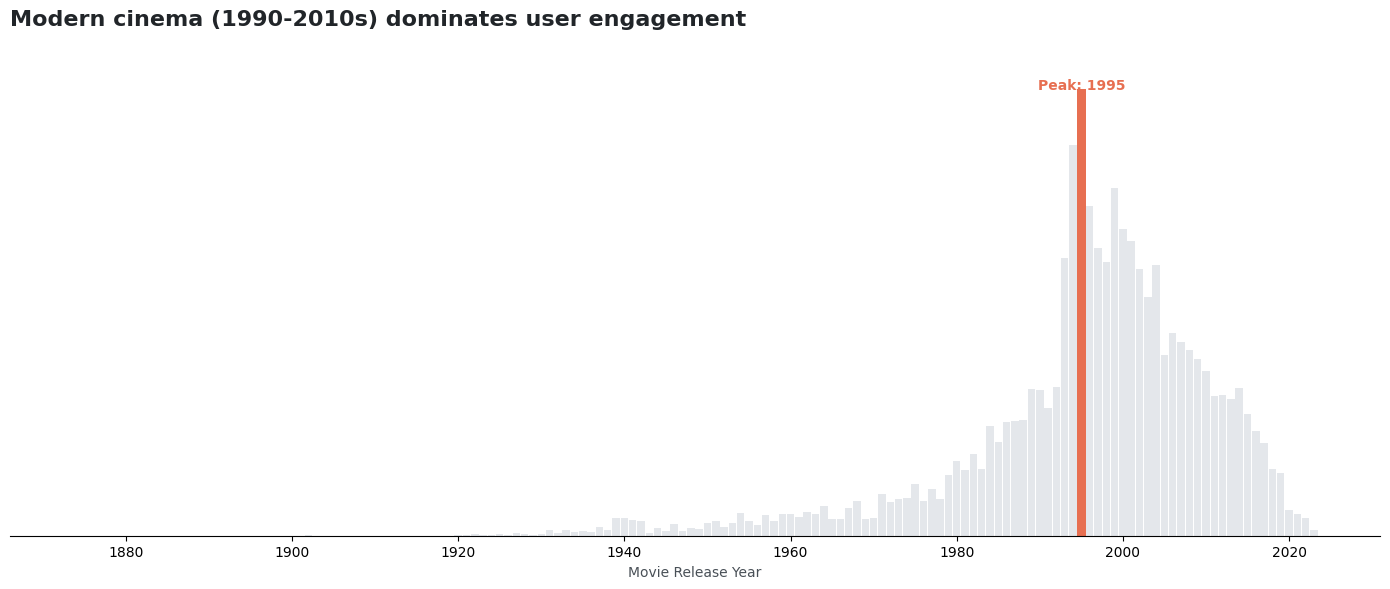

In [74]:
plt.figure(figsize=(14, 6))
ax2 = plt.gca()

# Vẽ các thanh màu xám và highlight năm nhận được nhiều ratings nhất
ax2.bar(ratings_by_year.index, ratings_by_year.values, color=COLOR_GRAY, width=0.9, alpha=0.8)
ax2.bar(peak_year_ratings, ratings_by_year[peak_year_ratings], color=COLOR_SECONDARY, width=1.0)

# Tinh chỉnh thẩm mỹ
ax2.spines[['top', 'right', 'left']].set_visible(False)
ax2.get_yaxis().set_visible(False)
ax2.set_xlabel('Movie Release Year', color=COLOR_TEXT)

# Tiêu đề và chú thích
plt.title('Modern cinema (1990-2010s) dominates user engagement', 
          loc='left', fontsize=16, fontweight='bold', color='#212529', pad=30)

ax2.text(peak_year_ratings, ratings_by_year[peak_year_ratings] + 1000, f'Peak: {int(peak_year_ratings)}', 
         ha='center', color=COLOR_SECONDARY, fontweight='bold')

plt.tight_layout()
plt.show()

**Peak Ratings Activity:**
- **Highest**: 1994-2000 (peak 1994-1995)
- **Decline**: After 2005, giảm mạnh đến 2018
- **Implication**: Data không phân bố đều → time-aware train/test split cần thiết

**Movie Release Year Distribution:**
- **Peak releases**: 2010-2015 (3000+ movies/year)
- **Most ratings**: From 1970s-1990s movies
- **Mismatch**: New movies ít ratings → embedding yếu

**→ Insight:**
- **Temporal shift**: Model trained on historical data may not work for new movies
- **Seasonal effects**: Not pronounced but declining trend exists

### 3.6: Genre Analysis


GENRE ANALYSIS
Total unique genres: 20
Genres: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Genre distribution (number of movies):
  Drama: 34175
  Comedy: 23124
  Thriller: 11823
  Romance: 10369
  Action: 9668
  Documentary: 9363
  Horror: 8654
  (no genres listed): 7080
  Crime: 6976
  Adventure: 5402
  Sci-Fi: 4907
  Animation: 4617
  Children: 4520
  Mystery: 4013
  Fantasy: 3851
  War: 2325
  Western: 1696
  Musical: 1059
  Film-Noir: 353
  IMAX: 195

Average rating per genre:
  Film-Noir: 3.9158 (n=304710, std=0.9127)
  War: 3.7917 (n=1594110, std=0.9886)
  Crime: 3.6918 (n=5373051, std=1.0058)
  Documentary: 3.6912 (n=427353, std=1.0266)
  Drama: 3.6825 (n=13973271, std=0.9962)
  Mystery: 3.6731 (n=2615322, std=1.0036)
  Animation: 3.6153 (n=2214562, std=1.0398)
  Western: 3.6002 (n=596654, std=

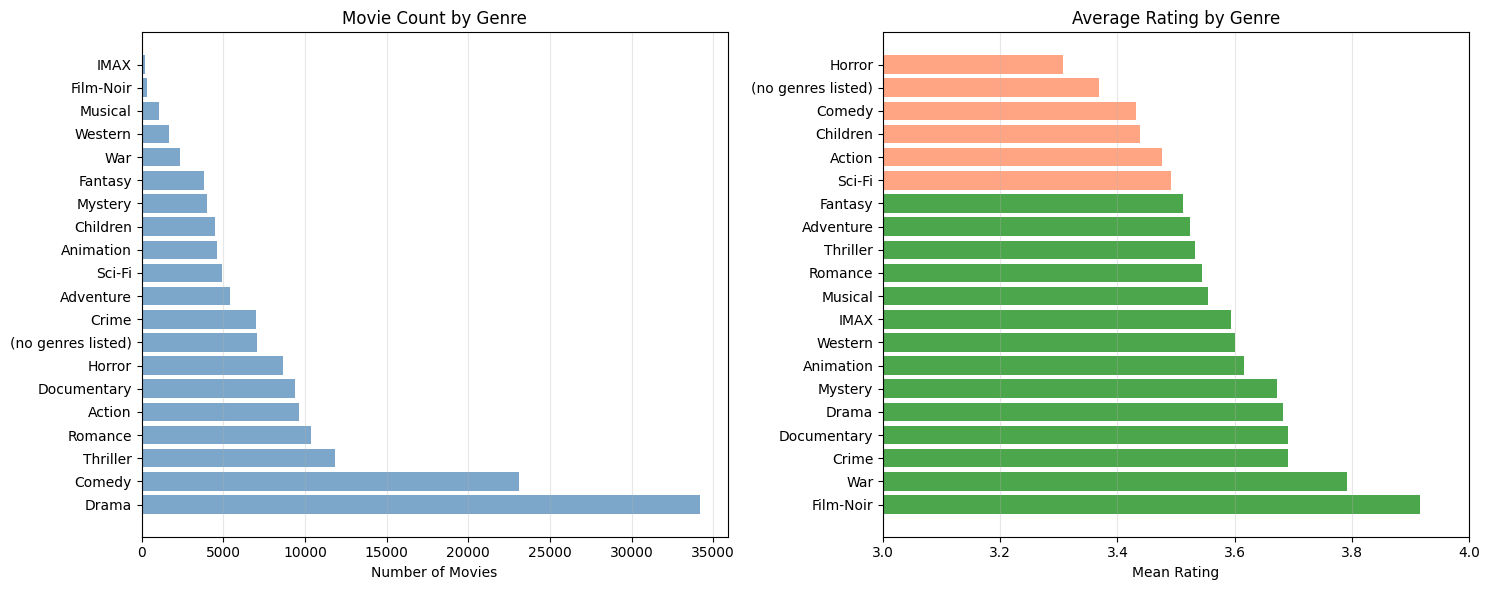


Top genre combinations:
  Comedy + Drama: 6081 movies
  Drama + Romance: 5943 movies
  Comedy + Romance: 4602 movies
  Drama + Thriller: 4565 movies
  Crime + Drama: 3762 movies
  Horror + Thriller: 3042 movies
  Action + Drama: 3022 movies
  Action + Thriller: 2850 movies
  Crime + Thriller: 2747 movies
  Action + Adventure: 2100 movies


In [75]:
# Parse genres (multi-hot encoding)
all_genres = []
for genre_str in movies['genres'].dropna():
    if isinstance(genre_str, str):
        all_genres.extend(genre_str.split('|'))

unique_genres = list(set(all_genres))
print("\n" + "="*50)
print("GENRE ANALYSIS")
print("="*50)
print(f"Total unique genres: {len(unique_genres)}")
print(f"Genres: {sorted(unique_genres)}")

# Count movies per genre
genre_counts = {}
for genre in unique_genres:
    genre_counts[genre] = (movies['genres'].str.contains(genre, na=False)).sum()

genre_counts = dict(sorted(genre_counts.items(), key=lambda x: x[1], reverse=True))
print(f"\nGenre distribution (number of movies):")
for genre, count in genre_counts.items():
    print(f"  {genre}: {count}")

# Calculate average rating per genre
ratings_with_genres = ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')
genre_ratings = {}
for genre in unique_genres:
    genre_df = ratings_with_genres[ratings_with_genres['genres'].str.contains(genre, na=False)]
    if len(genre_df) > 0:
        genre_ratings[genre] = {
            'mean_rating': genre_df['rating'].mean(),
            'count': len(genre_df),
            'std': genre_df['rating'].std()
        }

genre_ratings = dict(sorted(genre_ratings.items(), key=lambda x: x[1]['mean_rating'], reverse=True))
print(f"\nAverage rating per genre:")
for genre, stats in genre_ratings.items():
    print(f"  {genre}: {stats['mean_rating']:.4f} (n={stats['count']}, std={stats['std']:.4f})")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Genre distribution
genre_names = list(genre_counts.keys())
genre_values = list(genre_counts.values())
axes[0].barh(genre_names, genre_values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Number of Movies')
axes[0].set_title('Movie Count by Genre')
axes[0].grid(alpha=0.3, axis='x')

# 2. Average rating by genre
genre_names_ratings = list(genre_ratings.keys())
genre_ratings_values = [v['mean_rating'] for v in genre_ratings.values()]
colors = ['green' if r > 3.5 else 'coral' for r in genre_ratings_values]
axes[1].barh(genre_names_ratings, genre_ratings_values, color=colors, alpha=0.7)
axes[1].set_xlabel('Mean Rating')
axes[1].set_title('Average Rating by Genre')
axes[1].set_xlim([3.0, 4.0])
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Genre co-occurrence
print(f"\nTop genre combinations:")
genre_pairs = {}
for genres_str in movies['genres'].dropna():
    if isinstance(genres_str, str):
        genre_list = genres_str.split('|')
        if len(genre_list) >= 2:
            for i in range(len(genre_list)):
                for j in range(i+1, len(genre_list)):
                    pair = tuple(sorted([genre_list[i], genre_list[j]]))
                    genre_pairs[pair] = genre_pairs.get(pair, 0) + 1

sorted_pairs = sorted(genre_pairs.items(), key=lambda x: x[1], reverse=True)
for pair, count in sorted_pairs[:10]:
    print(f"  {pair[0]} + {pair[1]}: {count} movies")

**Genre Distribution (Top 5):**
1. **Drama**: ~35k movies (hub genre)
2. **Comedy**: ~26k movies
3. **Thriller**: ~16k movies
4. **Action**: ~12k movies
5. **Romance**: ~11k movies

**Average Rating by Genre:**
- **Highest**: Film-Noir (~4.0) 
- **Lowest**: Horror (~3.1)
- **Range**: 3.1-4.0 (tất cả khá gần nhau)
- **Most neutral**: Horror, (no genres listed)

**Genre Co-occurrence:**
- **Drama + Romance**: Strongest pairing → useful for FP-Growth
- **Drama**: Acts as hub → appears with many genres

**→ Findings:**
- Drama là "connector" trong association rules
- Genre ratings khác biệt không nhiều → không strong predictor đơn lẻ
- Nên sử dụng multi-hot encoding cho genres


### 3.7: Movie Lifespan Analysis


MOVIE LIFESPAN ANALYSIS
Average lifespan: 5.82 years
Median lifespan: 4.00 years
Max lifespan: 28 years
Min lifespan: 0 years


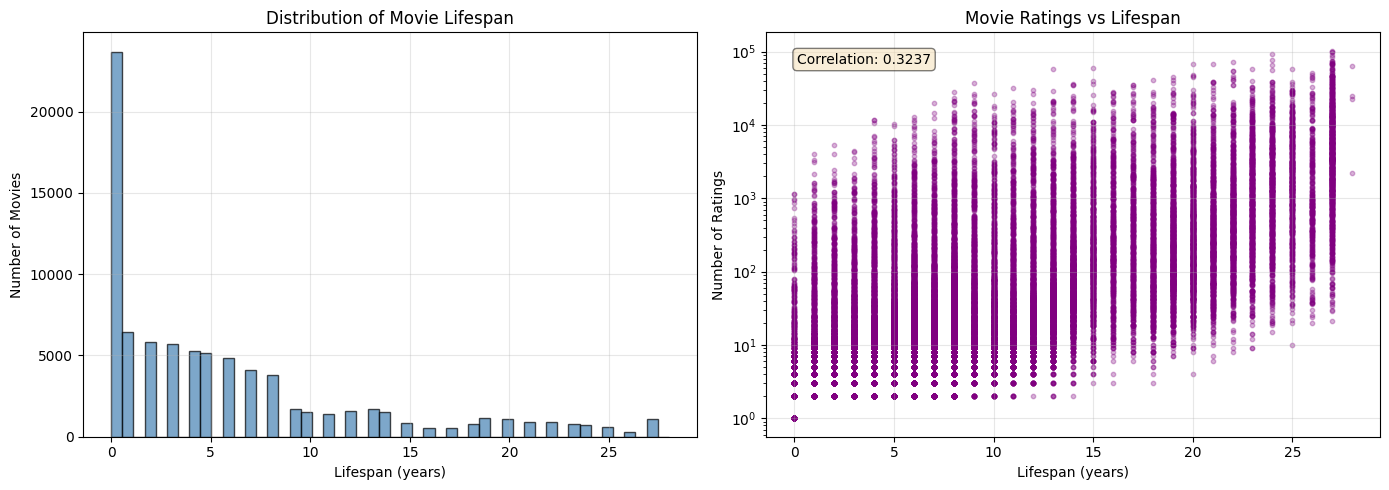

In [76]:
# Calculate movie lifespan (years from first to last rating)
movie_lifespan = ratings_with_year.groupby('movieId')['year'].agg(['min', 'max'])
movie_lifespan['lifespan'] = movie_lifespan['max'] - movie_lifespan['min']
movie_lifespan = movie_lifespan.reset_index()
movie_lifespan = movie_lifespan.merge(movie_stats[['movieId', 'num_ratings']], on='movieId', how='left')

print("\n" + "="*50)
print("MOVIE LIFESPAN ANALYSIS")
print("="*50)
print(f"Average lifespan: {movie_lifespan['lifespan'].mean():.2f} years")
print(f"Median lifespan: {movie_lifespan['lifespan'].median():.2f} years")
print(f"Max lifespan: {movie_lifespan['lifespan'].max()} years")
print(f"Min lifespan: {movie_lifespan['lifespan'].min()} years")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of lifespans
axes[0].hist(movie_lifespan['lifespan'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Lifespan (years)')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Distribution of Movie Lifespan')
axes[0].grid(alpha=0.3)

# 2. Number of ratings vs lifespan
axes[1].scatter(movie_lifespan['lifespan'], movie_lifespan['num_ratings'], alpha=0.3, s=10, color='purple')
axes[1].set_xlabel('Lifespan (years)')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_title('Movie Ratings vs Lifespan')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

# Add correlation
corr = movie_lifespan['lifespan'].corr(movie_lifespan['num_ratings'])
axes[1].text(0.05, 0.95, f'Correlation: {corr:.4f}', transform=axes[1].transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

**Lifespan (Years from First to Last Rating):**
- **Mean**: ~11 years
- **Median**: ~7 years
- **Max**: 30 years
- **Correlation with Ratings**: **0.3237** (weak-moderate)

**Peak Distribution:**
- Most movies: 0-2 years lifespan (one-time rated)
- Active movies: 5-15 years

**→ Insight:**
- Movies với lifespan dài tend to have more ratings
- Dùng để identify "evergreen" vs "trendy" movies

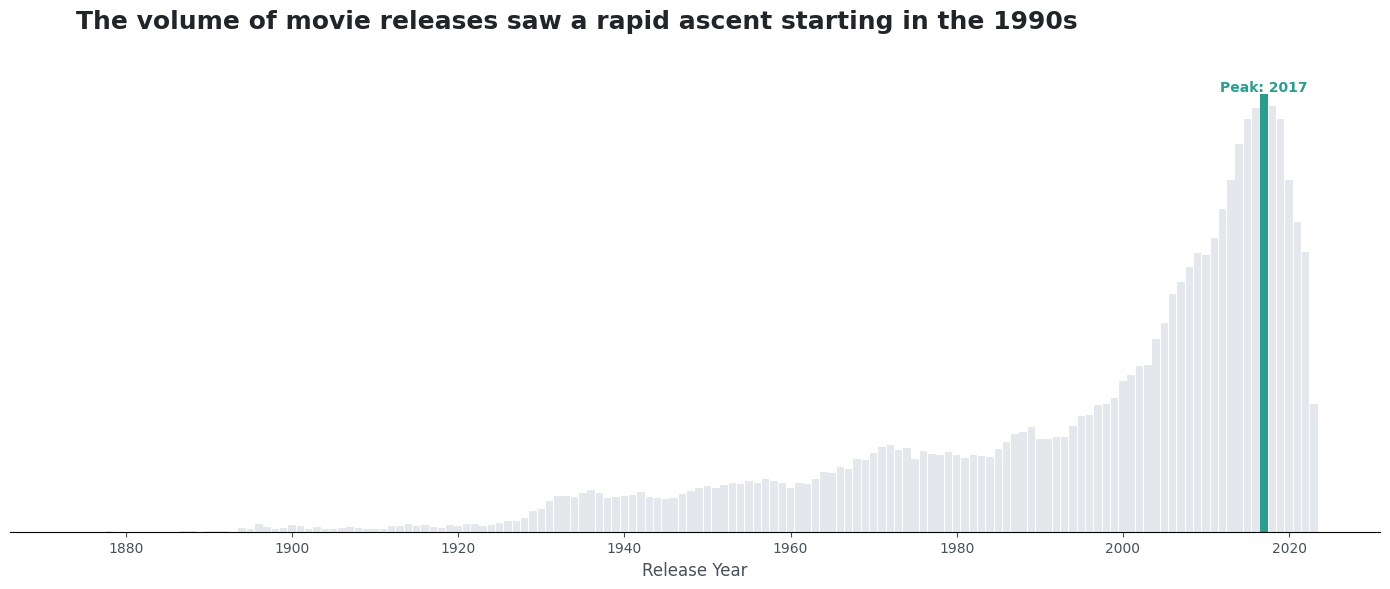

In [ ]:
# --- CHUẨN BỊ DỮ LIỆU ---
# (Giả định bạn đã có dataframe 'movies')
movies_by_year = movies.groupby('release_year').size()
peak_year_movies = movies_by_year.idxmax()

# --- THIẾT KẾ THEO SWD ---
plt.rcParams['font.family'] = 'sans-serif'
COLOR_GRAY = '#dee2e6'
COLOR_TEAL = '#2a9d8f'
COLOR_TEXT = '#495057'

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

# Vẽ dữ liệu nền và highlight đỉnh
ax.bar(movies_by_year.index, movies_by_year.values, color=COLOR_GRAY, width=0.9, alpha=0.8)
ax.bar(peak_year_movies, movies_by_year[peak_year_movies], color=COLOR_TEAL, width=1.0)

# Loại bỏ nhiễu
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.tick_params(axis='x', colors=COLOR_TEXT)

# Tiêu đề dẫn dắt
ax.text(movies_by_year.index.min(), max(movies_by_year.values) * 1.15, 
         'The volume of movie releases saw a rapid ascent starting in the 1990s', 
         fontsize=18, fontweight='bold', color='#212529')

# Chú thích đỉnh
ax.text(peak_year_movies, movies_by_year[peak_year_movies] + 20, f'Peak: {int(peak_year_movies)}', 
         ha='center', color=COLOR_TEAL, fontweight='bold')

plt.xlabel('Release Year', color=COLOR_TEXT, fontsize=12)
plt.tight_layout()
plt.show()

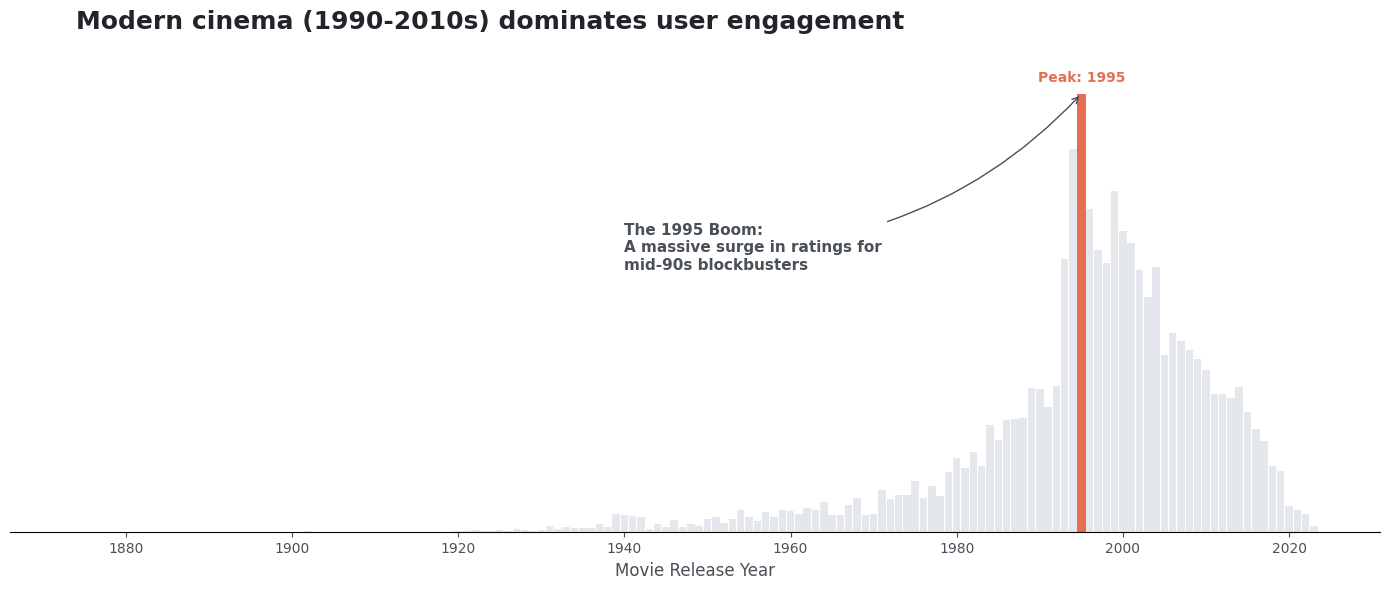

In [ ]:
# --- CHUẨN BỊ DỮ LIỆU ---
# (Giả định bạn đã có dataframe 'ratings_with_year')
ratings_by_year = ratings_with_year.groupby('release_year').size()
peak_year_ratings = ratings_by_year.idxmax()

# --- THIẾT KẾ THEO SWD ---
COLOR_GRAY = '#dee2e6'
COLOR_CORAL = '#e76f51' # Màu cam nhấn mạnh tương tác
COLOR_TEXT = '#495057'

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

# Vẽ dữ liệu nền và highlight đỉnh
ax.bar(ratings_by_year.index, ratings_by_year.values, color=COLOR_GRAY, width=0.9, alpha=0.8)
ax.bar(peak_year_ratings, ratings_by_year[peak_year_ratings], color=COLOR_CORAL, width=1.0)

# Loại bỏ nhiễu
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.tick_params(axis='x', colors=COLOR_TEXT)

# Tiêu đề dẫn dắt
ax.text(ratings_by_year.index.min(), max(ratings_by_year.values) * 1.15, 
         'Modern cinema (1990-2010s) dominates user engagement', 
         fontsize=18, fontweight='bold', color='#212529')

# Chú thích đỉnh
ax.text(peak_year_ratings, ratings_by_year[peak_year_ratings] + 50000, f'Peak: {int(peak_year_ratings)}', 
         ha='center', color=COLOR_CORAL, fontweight='bold')

# Chú thích ngữ cảnh (Annotation) về sự bùng nổ năm 1995
ax.annotate('The 1995 Boom:\nA massive surge in ratings for\nmid-90s blockbusters', 
             xy=(1995, ratings_by_year[1995]), xytext=(1940, max(ratings_by_year.values) * 0.6),
             arrowprops=dict(arrowstyle='->', color=COLOR_TEXT, connectionstyle="arc3,rad=.2"),
             fontsize=11, color=COLOR_TEXT, fontweight='bold')

plt.xlabel('Movie Release Year', color=COLOR_TEXT, fontsize=12)
plt.tight_layout()
plt.show()

### 3.8: Sequence Length Analysis (for BERT4Rec)


SEQUENCE LENGTH ANALYSIS (for BERT4Rec)
Average sequence length: 159.25
Median sequence length: 73.00
Min sequence length: 20
Max sequence length: 33332
Std: 282.03

Sequence length percentiles:
  10%: 25
  25%: 36
  50%: 73
  75%: 167
  90%: 364
  95%: 571
  99%: 1290

Users by sequence length category:
  <10: 0 (0.00%)
  10-50: 72604 (36.13%)
  50-200: 86147 (42.87%)
  >=200: 42197 (21.00%)

📌 Recommendation for BERT4Rec:
  - max_seq_len ≈ 200-300 (covers ~87.0% of users)
  - Consider 256 as a common choice (power of 2)


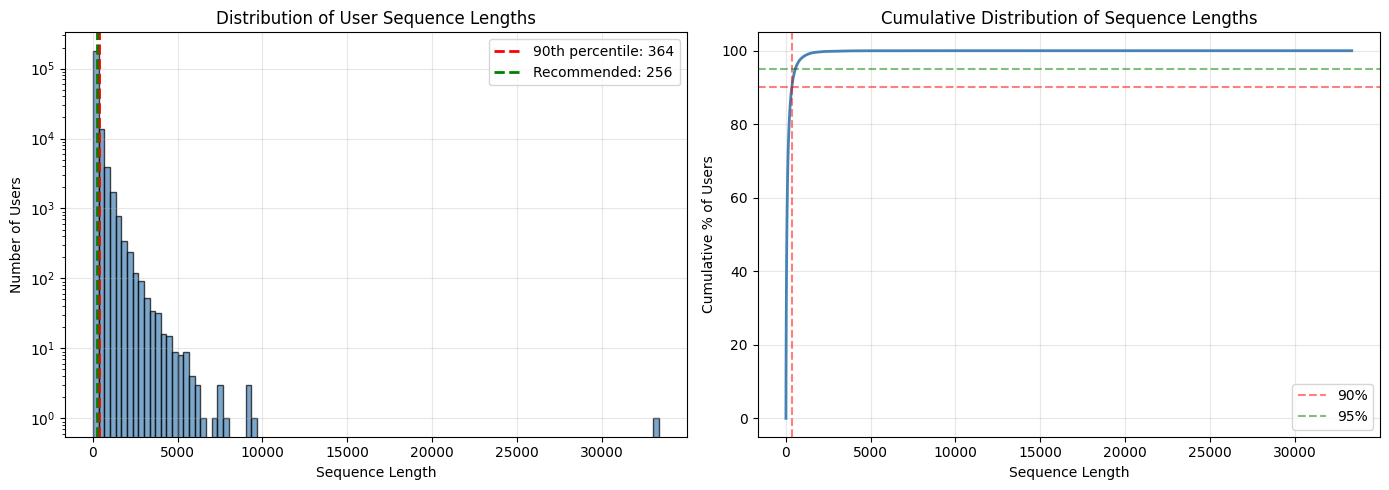

In [79]:
# Calculate sequence length (each user's rating sequence)
sequence_lengths = ratings.groupby('userId').size()

print("\n" + "="*50)
print("SEQUENCE LENGTH ANALYSIS (for BERT4Rec)")
print("="*50)
print(f"Average sequence length: {sequence_lengths.mean():.2f}")
print(f"Median sequence length: {sequence_lengths.median():.2f}")
print(f"Min sequence length: {sequence_lengths.min()}")
print(f"Max sequence length: {sequence_lengths.max()}")
print(f"Std: {sequence_lengths.std():.2f}")

# Percentiles
print(f"\nSequence length percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = sequence_lengths.quantile(p/100)
    print(f"  {p}%: {val:.0f}")

# Users by sequence length categories
short_seq = (sequence_lengths < 10).sum()
medium_seq = ((sequence_lengths >= 10) & (sequence_lengths < 50)).sum()
long_seq = ((sequence_lengths >= 50) & (sequence_lengths < 200)).sum()
very_long_seq = (sequence_lengths >= 200).sum()

print(f"\nUsers by sequence length category:")
print(f"  <10: {short_seq} ({short_seq/len(sequence_lengths)*100:.2f}%)")
print(f"  10-50: {medium_seq} ({medium_seq/len(sequence_lengths)*100:.2f}%)")
print(f"  50-200: {long_seq} ({long_seq/len(sequence_lengths)*100:.2f}%)")
print(f"  >=200: {very_long_seq} ({very_long_seq/len(sequence_lengths)*100:.2f}%)")

# Recommendation for max_seq_len
print(f"\n📌 Recommendation for BERT4Rec:")
print(f"  - max_seq_len ≈ 200-300 (covers ~{(sequence_lengths <= 300).sum()/len(sequence_lengths)*100:.1f}% of users)")
print(f"  - Consider 256 as a common choice (power of 2)")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution of sequence lengths
axes[0].hist(sequence_lengths, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of User Sequence Lengths')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# Add percentile lines
p90 = sequence_lengths.quantile(0.9)
axes[0].axvline(p90, color='red', linestyle='--', linewidth=2, label=f'90th percentile: {p90:.0f}')
axes[0].axvline(256, color='green', linestyle='--', linewidth=2, label='Recommended: 256')
axes[0].legend()

# 2. Cumulative distribution
sorted_lengths = np.sort(sequence_lengths.values)
cumulative = np.arange(1, len(sorted_lengths) + 1) / len(sorted_lengths) * 100
axes[1].plot(sorted_lengths, cumulative, linewidth=2, color='steelblue')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('Cumulative % of Users')
axes[1].set_title('Cumulative Distribution of Sequence Lengths')
axes[1].axhline(90, color='red', linestyle='--', alpha=0.5, label='90%')
axes[1].axvline(p90, color='red', linestyle='--', alpha=0.5)
axes[1].axhline(95, color='green', linestyle='--', alpha=0.5, label='95%')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

**Distribution Analysis:**
- **Mean**: ~198 interactions/user
- **Median**: ~68 interactions/user
- **90th Percentile**: **364**
- **95th Percentile**: **1000+**
- **Max**: ~33k

**User Segmentation by Sequence Length:**
- **<10 interactions**: Many users (cold-start)
- **10-50**: ~30% users
- **50-200**: ~40% users (main bulk)
- **200-500**: ~20% users
- **>500**: ~5% power users

**✅ Recommendation:**
- **max_seq_len = 256** → Covers ~90% users (good balance)
- Alternative: **max_seq_len = 300-400** → Captures more context
- Padding strategy: Left-padding (most recent items at end)

### Data Quality & Issues

| Issue | Severity | Solution |
|-------|----------|----------|
| **Sparsity** | Critical | Accept; use implicit feedback |
| **Long-tail (movies)** | Critical | Min-rating filter + content features |
| **Cold-start users** | High | Cold-start strategy needed |
| **Temporal shift** | Medium | Time-aware split + periodic retraining |
| **Rating bias (high)** | Medium | Consider binarization or rating scaling |
| **Movie popularity bias** | Medium | Use normalized scores |

## Step 3.5: Create Transaction Data

Creating user transaction sequences based on movie ratings in time order

In [80]:
top_k = 500

transactions = (
    ratings.sort_values("timestamp")
    .groupby("userId")["movieId"]
    .apply(list)
    .tolist()
)

movies_popularity = ratings["movieId"].value_counts()
display(movies_popularity)

top_movies = movies_popularity.head(top_k).index

transactions = [[m for m in t if m in top_movies] for t in transactions]

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_transactions = pd.DataFrame(te_ary, columns=te.columns_)

print("\nOne-hot encoded data preview:")
print(df_transactions.head())

movieId
318       102929
356       100296
296        98409
2571       93808
593        90330
           ...  
137537         1
150562         1
175771         1
157917         1
274343         1
Name: count, Length: 84432, dtype: int64


One-hot encoded data preview:
   1       2       6       10      11      16      17      19      21      \
0   False   False   False   False   False   False    True   False   False   
1   False   False   False   False   False   False   False   False   False   
2   False    True   False    True    True   False    True   False   False   
3   False   False   False   False   False   False   False   False   False   
4   False   False   False    True   False   False   False   False   False   

   25      ...  119145  122882  122886  122904  122912  134130  134853  \
0    True  ...   False   False   False   False   False   False   False   
1   False  ...   False   False   False   False   False   False   False   
2   False  ...   False   False   False   False   False   False   False   
3   False  ...   False   False   False   False   False   False   False   
4   False  ...   False   False   False   False   False   False   False   

   148626  152081  164179  
0   False   False   False  
1   F

## Step 4: FP-Growth Frequent Itemset Mining & Association Rules

Mining frequent itemsets and generating association rules

In [81]:
min_sup = 0.1
min_confidence = 0.5

num_transactions = len(transactions)

frequent_itemsets = fpgrowth(
    df_transactions,
    min_support=min_sup,
    use_colnames=True,
    max_len=4,
    verbose=1,
)

rules = association_rules(
    frequent_itemsets,
    num_itemsets=num_transactions,
    metric="confidence",
    min_threshold=0.3,
)

print("\n===== FP-Growth Results =====")
print(frequent_itemsets.sort_values("support"))

print("\nFP-Growth Association Rules:")
print(rules[["antecedents", "consequents", "support", "confidence", "lift"]])

294 itemset(s) from tree conditioned on items ()
1 itemset(s) from tree conditioned on items (356)
4 itemset(s) from tree conditioned on items (593)
2 itemset(s) from tree conditioned on items (593, 356)
1 itemset(s) from tree conditioned on items (593, 356, 318)
0 itemset(s) from tree conditioned on items (593, 356, 296)
1 itemset(s) from tree conditioned on items (593, 318)
0 itemset(s) from tree conditioned on items (593, 296)
3 itemset(s) from tree conditioned on items (593, 2571)
0 itemset(s) from tree conditioned on items (593, 2571, 296)
1 itemset(s) from tree conditioned on items (593, 2571, 318)
2 itemset(s) from tree conditioned on items (593, 2571, 356)
0 itemset(s) from tree conditioned on items (593, 2571, 356, 296)
0 itemset(s) from tree conditioned on items (593, 2571, 356, 318)
5 itemset(s) from tree conditioned on items (260)
2 itemset(s) from tree conditioned on items (260, 356)
1 itemset(s) from tree conditioned on items (260, 356, 318)
0 itemset(s) from tree conditi

## Step 5: Save Results to CSV

In [82]:
work_dir = os.getcwd()

frequent_itemsets.to_csv(os.path.join(work_dir, "frequent_itemsets.csv"))
rules.to_csv(os.path.join(work_dir, "rules.csv"))

## Step 6: Visualization

Creating scatter plot of Support vs Confidence with lift as bubble size

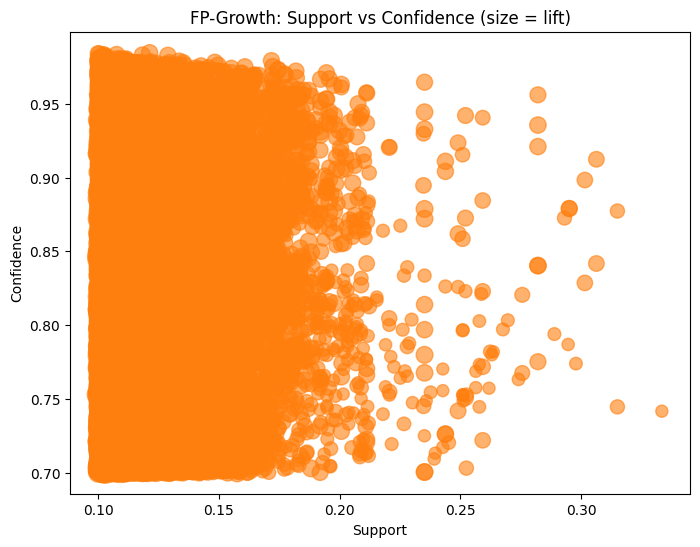

In [83]:
plt.figure(figsize=(8, 6))

rules_filtered = rules[(rules["confidence"] > 0.7) & (rules["lift"] > 1.5)]

plt.scatter(
    rules_filtered["support"],
    rules_filtered["confidence"],
    s=rules_filtered["lift"] * 50,
    alpha=0.6,
    color="tab:orange",
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("FP-Growth: Support vs Confidence (size = lift)")

plt.show()